# 3. Hypothesenanalyse - Titanic Dataset

In diesem Notebook pruefen wir die drei Hypothesen H1-H3 mit statistischen Tests.

## Ziele
- H1: Zusammenhang zwischen Geschlecht und Ueberleben pruefen
- H2: Zusammenhang zwischen Klasse und Ueberleben pruefen
- H3: Altersunterschiede zwischen Ueberlebenden und Nicht-Ueberlebenden pruefen

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)



## 3.1 Daten laden

In [8]:
data_path = Path('../data/processed/titanic_cleaned.csv')
df = pd.read_csv(data_path)

print(f'Daten geladen: {data_path}')
print(f'Zeilen: {df.shape[0]} | Spalten: {df.shape[1]}')
display(df.head())

Daten geladen: ..\data\processed\titanic_cleaned.csv
Zeilen: 891 | Spalten: 12


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,who,adult_male,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,S,man,True,Southampton,False
1,1,1,female,38.0,1,0,71.2833,C,woman,False,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,S,woman,False,Southampton,True
3,1,1,female,35.0,1,0,53.1000,S,woman,False,Southampton,False
4,0,3,male,35.0,0,0,8.0500,S,man,True,Southampton,True


## 3.2 Vorbereitung der Spaltennamen

In [9]:
target_col = 'Survived' if 'Survived' in df.columns else 'survived'
sex_col = 'Sex' if 'Sex' in df.columns else 'sex'
pclass_col = 'Pclass' if 'Pclass' in df.columns else 'pclass'
age_col = 'Age' if 'Age' in df.columns else 'age'
fare_col = 'Fare' if 'Fare' in df.columns else 'fare'

print('Verwendete Spalten:')
print('target:', target_col)
print('sex   :', sex_col)
print('pclass:', pclass_col)
print('age   :', age_col)
print('fare  :', fare_col)

Verwendete Spalten:
target: Survived
sex   : Sex
pclass: Pclass
age   : Age
fare  : Fare


## 3.3 H1: Weibliche Passagiere hatten eine hoehere Ueberlebenswahrscheinlichkeit

In [10]:
h1_table = pd.crosstab(df[sex_col], df[target_col])
h1_rate = df.groupby(sex_col)[target_col].mean().sort_values(ascending=False)

chi2_h1, p_h1, dof_h1, _ = chi2_contingency(h1_table)

print('Kontingenztafel (Sex x Survived):')
display(h1_table)
print('Ueberlebensraten nach Geschlecht:')
display((h1_rate * 100).round(2).rename('survival_rate_percent'))
print(f'Chi2 = {chi2_h1:.4f}, p-Wert = {p_h1:.6f}, dof = {dof_h1}')
print('Ergebnis:', 'H1 unterstuetzt' if p_h1 < 0.05 and h1_rate.index[0].lower() == 'female' else 'H1 nicht eindeutig unterstuetzt')

Kontingenztafel (Sex x Survived):


Survived,0,1
Sex,,
female,81,233
male,468,109


Ueberlebensraten nach Geschlecht:


Sex
female    74.20
male      18.89
Name: survival_rate_percent, dtype: float64

Chi2 = 260.7170, p-Wert = 0.000000, dof = 1
Ergebnis: H1 unterstuetzt


C:\Users\moham\AppData\Local\Temp\ipykernel_14544\4126535468.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=h1_rate.index, y=h1_rate.values * 100, palette='Set2')


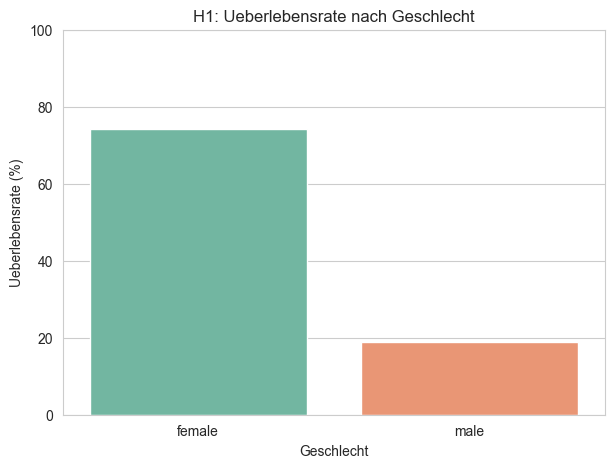

In [11]:
plt.figure(figsize=(7, 5))
sns.barplot(x=h1_rate.index, y=h1_rate.values * 100, palette='Set2')
plt.title('H1: Ueberlebensrate nach Geschlecht')
plt.xlabel('Geschlecht')
plt.ylabel('Ueberlebensrate (%)')
plt.ylim(0, 100)
plt.show()

## 3.4 H2: 1. Klasse hatte hoehere Ueberlebenswahrscheinlichkeit als 3. Klasse

In [12]:
h2_table = pd.crosstab(df[pclass_col], df[target_col])
h2_rate = df.groupby(pclass_col)[target_col].mean().sort_index()

chi2_h2, p_h2, dof_h2, _ = chi2_contingency(h2_table)

print('Kontingenztafel (Pclass x Survived):')
display(h2_table)
print('Ueberlebensraten nach Klasse:')
display((h2_rate * 100).round(2).rename('survival_rate_percent'))
print(f'Chi2 = {chi2_h2:.4f}, p-Wert = {p_h2:.6f}, dof = {dof_h2}')

h2_supported = (p_h2 < 0.05) and (h2_rate.loc[1] > h2_rate.loc[3])
print('Ergebnis:', 'H2 unterstuetzt' if h2_supported else 'H2 nicht eindeutig unterstuetzt')

Kontingenztafel (Pclass x Survived):


Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


Ueberlebensraten nach Klasse:


Pclass
1    62.96
2    47.28
3    24.24
Name: survival_rate_percent, dtype: float64

Chi2 = 102.8890, p-Wert = 0.000000, dof = 2
Ergebnis: H2 unterstuetzt


C:\Users\moham\AppData\Local\Temp\ipykernel_14544\1632458443.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=h2_rate.index.astype(str), y=h2_rate.values * 100, palette='Blues')


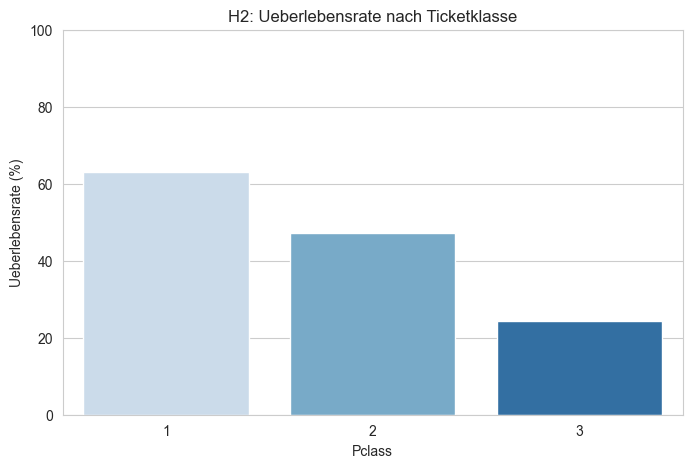

In [13]:
plt.figure(figsize=(8, 5))
sns.barplot(x=h2_rate.index.astype(str), y=h2_rate.values * 100, palette='Blues')
plt.title('H2: Ueberlebensrate nach Ticketklasse')
plt.xlabel('Pclass')
plt.ylabel('Ueberlebensrate (%)')
plt.ylim(0, 100)
plt.show()

In [14]:
fare_by_class = df.groupby(pclass_col)[fare_col].describe()[['count', 'mean', 'std', 'min', 'max']]
print('Fare-Zusammenfassung nach Klasse:')
display(fare_by_class.round(2))

Fare-Zusammenfassung nach Klasse:


,count,mean,std,min,max
Pclass,,,,,
1,216.0,84.15,78.38,0.0,512.33
2,184.0,20.66,13.42,0.0,73.50
3,491.0,13.68,11.78,0.0,69.55


## 3.5 H3: Juengere Passagiere hatten hoehere Ueberlebenswahrscheinlichkeit

In [15]:
age_survived = df.loc[df[target_col] == 1, age_col]
age_not_survived = df.loc[df[target_col] == 0, age_col]

t_stat, p_t = ttest_ind(age_survived, age_not_survived, equal_var=False, nan_policy='omit')
u_stat, p_u = mannwhitneyu(age_survived, age_not_survived, alternative='two-sided')

print(f'Mittleres Alter (ueberlebt): {age_survived.mean():.2f}')
print(f'Mittleres Alter (nicht ueberlebt): {age_not_survived.mean():.2f}')
print(f't-Test: t = {t_stat:.4f}, p-Wert = {p_t:.6f}')
print(f'Mann-Whitney-U: U = {u_stat:.4f}, p-Wert = {p_u:.6f}')

h3_supported = (p_t < 0.05) and (age_survived.mean() < age_not_survived.mean())
print('Ergebnis:', 'H3 unterstuetzt' if h3_supported else 'H3 nicht eindeutig unterstuetzt')

Mittleres Alter (ueberlebt): 28.29
Mittleres Alter (nicht ueberlebt): 30.03
t-Test: t = -1.8966, p-Wert = 0.058309
Mann-Whitney-U: U = 89779.5000, p-Wert = 0.269673
Ergebnis: H3 nicht eindeutig unterstuetzt


C:\Users\moham\AppData\Local\Temp\ipykernel_14544\3491245309.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=age_col, palette='Set3')


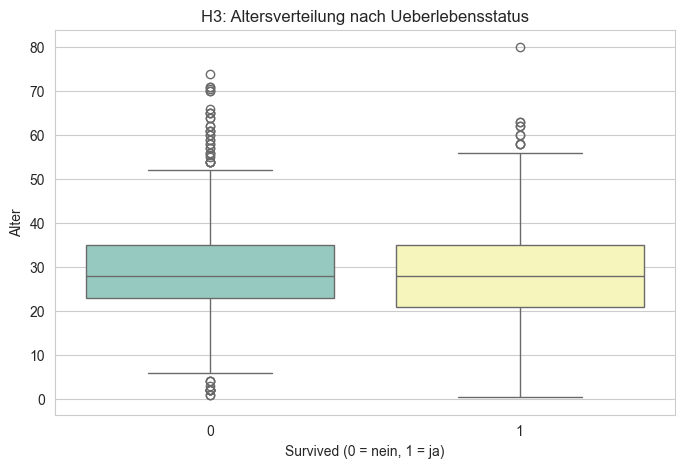

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x=target_col, y=age_col, palette='Set3')
plt.title('H3: Altersverteilung nach Ueberlebensstatus')
plt.xlabel('Survived (0 = nein, 1 = ja)')
plt.ylabel('Alter')
plt.show()

## 3.6 Zusammenfassung der Hypothesen

- **H1** wird unterstützt, wenn p < 0.05 und Frauen eine höhere Ueberlebensrate haben.
- **H2** wird unterstützt, wenn p < 0.05 und Klasse 1 eine höhere Ueberlebensrate als Klasse 3 hat.
- **H3** wird unterstützt, wenn p < 0.05 und das Durchschnittsalter der Ueberlebenden niedriger ist.

